## CREDIT SCORING MODEL

### 1. IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

### 2. LOAD DATASET

In [ ]:
df = pd.read_csv('/content/german_credit_data.csv',delimiter=',')


# Display first 5 rows
print(df.head())

   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  
0           1169         6             radio/TV  
1           5951        48             radio/TV  
2           2096        12            education  
3           7882        42  furniture/equipment  
4           4870        24                  car  


### 3. DATA UNDERSTANDING

In [ ]:
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape:
(1000, 10)

Column Names:
Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB
None

Missing Values:
Unnamed: 0            0
Age                

### 4. HANDLE MISSING VALUES

In [ ]:
# Fill categorical missing values with mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Fill numerical missing values with median
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_1350/3416661908.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_1350/3416661908.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

### 5. FEATURE ENGINEERING

In [ ]:
# Creating Age Group Feature

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[18, 30, 45, 60, 100],
    labels=['Young', 'Adult', 'Middle_Age', 'Senior']
)

# Loan Amount Per Duration Feature

df['Loan_Per_Month'] = df['Credit amount'] / df['Duration']

### 6. ENCODE CATEGORICAL VARIABLES

In [ ]:
label_encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = label_encoder.fit_transform(df[col])

# Encode newly created Age_Group column
df['Age_Group'] = label_encoder.fit_transform(df['Age_Group'])

### 7. DEFINE FEATURES AND TARGET

In [ ]:
# Define features and target using the 'Loan_Risk' column
target_column = 'Loan_Risk'

X = df.drop(['Loan_Per_Month', target_column], axis=1) # Drop original continuous and the new target
y = df[target_column]

print(f"Target Column: {target_column}")
print("Distribution of target variable:")
print(y.value_counts())

Target Column: Loan_Risk
Distribution of target variable:
Loan_Risk
1    500
0    500
Name: count, dtype: int64


### 8. FEATURE SCALING

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 9. TRAIN-TEST SPLIT (Re-run with new target)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # Stratify to maintain class balance in train/test sets
)

### 10. TRAIN MODELS (Re-run with new target)

In [ ]:
# Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### 11. MODEL EVALUATION FUNCTION

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)

    # Probability prediction for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"\n================ {model_name} ================")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fig_roc, ax_roc = plt.subplots(figsize=(7, 6))
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax_roc)
    plt.title(f'{model_name} - ROC Curve')
    plt.tight_layout()
    plt.show()

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

### 12. EVALUATE ALL MODELS

Logistic Regression

================ Logistic Regression ================
Accuracy  : 0.9800
Precision : 0.9898
Recall    : 0.9700
F1-Score  : 0.9798
ROC-AUC   : 0.9990

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       100
           1       0.99      0.97      0.98       100

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



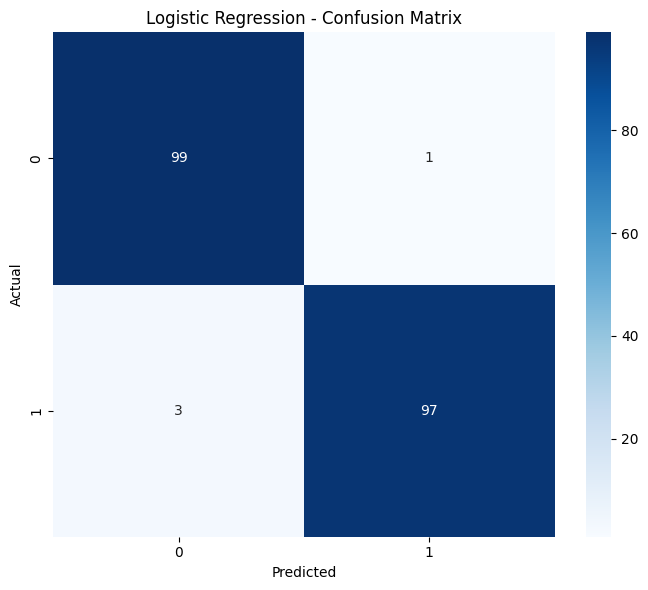

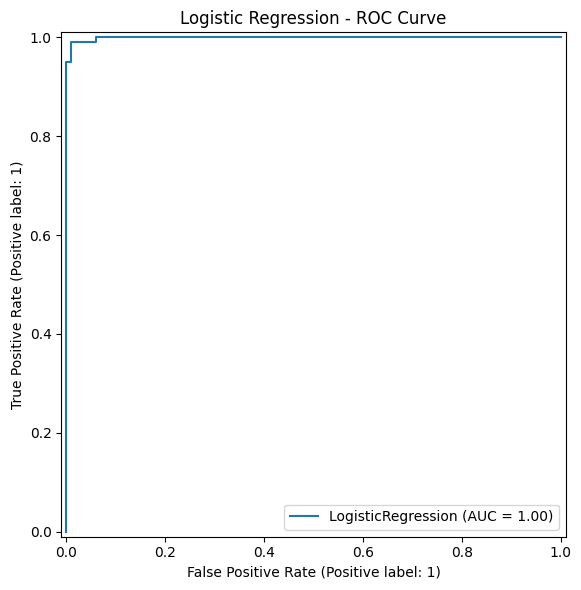

In [ ]:
print("Logistic Regression")
lr_metrics = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")

Decision Tree

================ Decision Tree ================
Accuracy  : 0.9550
Precision : 0.9252
Recall    : 0.9900
F1-Score  : 0.9565
ROC-AUC   : 0.9550

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95       100
           1       0.93      0.99      0.96       100

    accuracy                           0.95       200
   macro avg       0.96      0.96      0.95       200
weighted avg       0.96      0.95      0.95       200



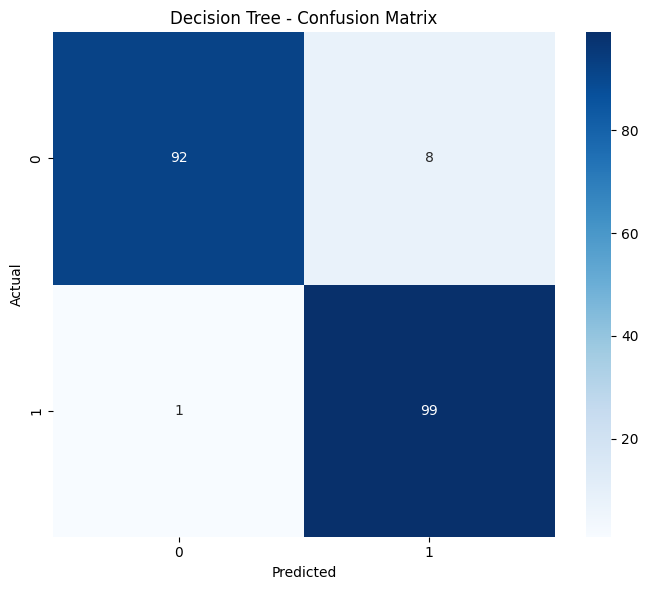

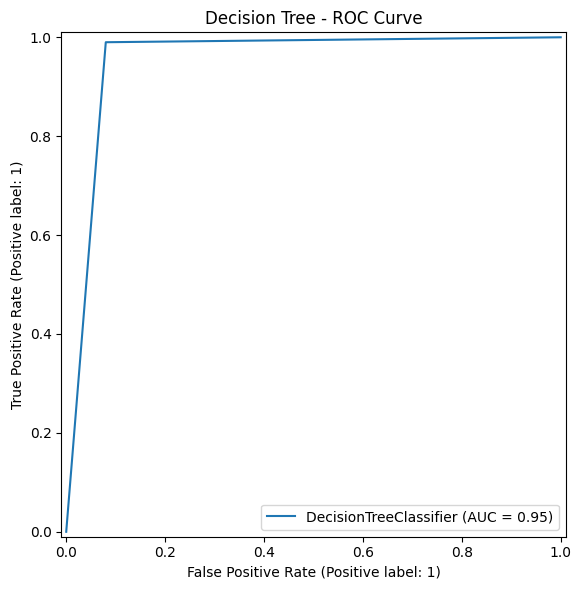

In [ ]:
print("Decision Tree")
dt_metrics = evaluate_model(dt_model, X_test, y_test, "Decision Tree")

Random Forest

================ Random Forest ================
Accuracy  : 0.9250
Precision : 0.8972
Recall    : 0.9600
F1-Score  : 0.9275
ROC-AUC   : 0.9763

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.89      0.92       100
           1       0.90      0.96      0.93       100

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.92       200
weighted avg       0.93      0.93      0.92       200



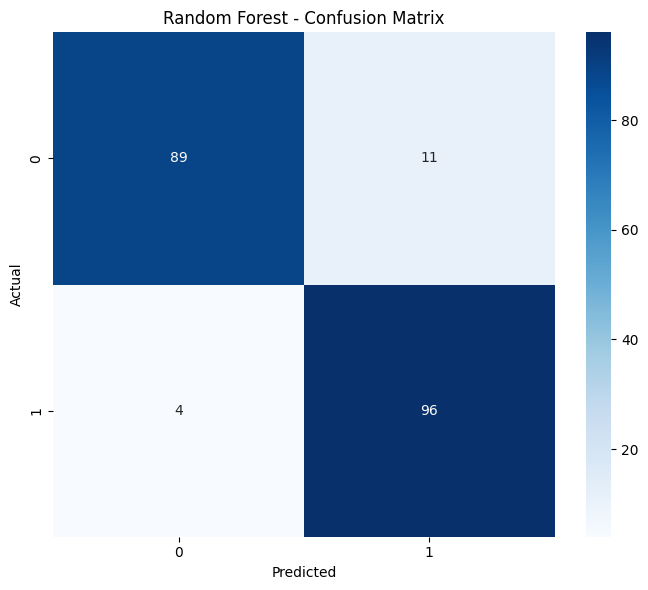

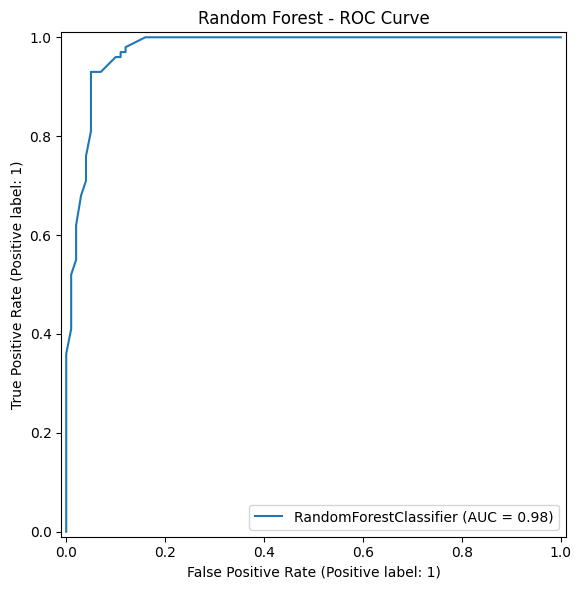

In [ ]:
print("Random Forest")
rf_metrics = evaluate_model(rf_model, X_test, y_test, "Random Forest")

### 13. FEATURE IMPORTANCE (RANDOM FOREST)


Top Important Features:
             Feature  Importance
7      Credit amount    0.470171
8           Duration    0.233147
0         Unnamed: 0    0.080333
1                Age    0.062747
9            Purpose    0.041370
3                Job    0.034756
6   Checking account    0.020697
4            Housing    0.016153
10         Age_Group    0.014881
5    Saving accounts    0.014737


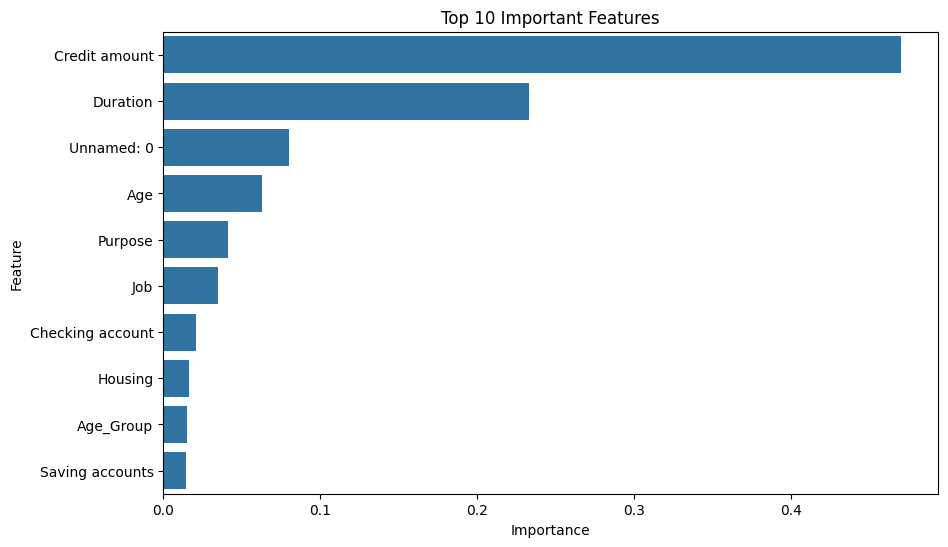

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Important Features:")
print(feature_importance.head(10))

# Plot Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title('Top 10 Important Features')
plt.show()

### 14. FINAL RESULT

In [ ]:
print("\nProject Completed Successfully!")
print("Models Used:")
print("1. Logistic Regression")
print(f"   - Accuracy: {lr_metrics['Accuracy']:.4f}, Precision: {lr_metrics['Precision']:.4f}, Recall: {lr_metrics['Recall']:.4f}, F1-Score: {lr_metrics['F1-Score']:.4f}, ROC-AUC: {lr_metrics['ROC-AUC']:.4f}")
print("2. Decision Tree")
print(f"   - Accuracy: {dt_metrics['Accuracy']:.4f}, Precision: {dt_metrics['Precision']:.4f}, Recall: {dt_metrics['Recall']:.4f}, F1-Score: {dt_metrics['F1-Score']:.4f}, ROC-AUC: {dt_metrics['ROC-AUC']:.4f}")
print("3. Random Forest")
print(f"   - Accuracy: {rf_metrics['Accuracy']:.4f}, Precision: {rf_metrics['Precision']:.4f}, Recall: {rf_metrics['Recall']:.4f}, F1-Score: {rf_metrics['F1-Score']:.4f}, ROC-AUC: {rf_metrics['ROC-AUC']:.4f}")

print("\nEvaluation Metrics Used:")
print("- Accuracy")
print("- Precision")
print("- Recall")
print("- F1-Score")
print("- ROC-AUC")


Project Completed Successfully!
Models Used:
1. Logistic Regression
   - Accuracy: 0.9800, Precision: 0.9898, Recall: 0.9700, F1-Score: 0.9798, ROC-AUC: 0.9990
2. Decision Tree
   - Accuracy: 0.9550, Precision: 0.9252, Recall: 0.9900, F1-Score: 0.9565, ROC-AUC: 0.9550
3. Random Forest
   - Accuracy: 0.9250, Precision: 0.8972, Recall: 0.9600, F1-Score: 0.9275, ROC-AUC: 0.9763

Evaluation Metrics Used:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
